# 2.5 DC Resisitivy inversion using BFGS as preconditioner

In [1]:
import pathlib
import time

import discretize
import matplotlib.pyplot as plt
import numpy as np
import pooch
import simpeg
from matplotlib.colors import LogNorm
from simpeg.electromagnetics.static import resistivity as dc

import inversion_ideas as ii

## Load data

In [2]:
url = "https://github.com/simpeg/user-tutorials/raw/main/assets/05-dcr/inv_dcr_2d_files.tar.gz"

fnames = pooch.retrieve(url, known_hash=None, processor=pooch.Untar())
fnames = [pathlib.Path(f) for f in fnames]
fnames

[PosixPath('/home/santi/.cache/pooch/a567d6514bf50ed948b5d7b7e4125664-inv_dcr_2d_files.tar.gz.untar/inv_dcr_2d_files/topo_2d.txt'),
 PosixPath('/home/santi/.cache/pooch/a567d6514bf50ed948b5d7b7e4125664-inv_dcr_2d_files.tar.gz.untar/inv_dcr_2d_files/dc_data.obs')]

In [3]:
(topo_fname,) = [f for f in fnames if "topo_2d.txt" in f.name]
(data_fname,) = [f for f in fnames if "dc_data.obs" in f.name]
topo_fname, data_fname

(PosixPath('/home/santi/.cache/pooch/a567d6514bf50ed948b5d7b7e4125664-inv_dcr_2d_files.tar.gz.untar/inv_dcr_2d_files/topo_2d.txt'),
 PosixPath('/home/santi/.cache/pooch/a567d6514bf50ed948b5d7b7e4125664-inv_dcr_2d_files.tar.gz.untar/inv_dcr_2d_files/dc_data.obs'))

In [4]:
# Load 2D topography
topo_2d = np.loadtxt(str(topo_fname))

In [5]:
voltage_data = simpeg.utils.io_utils.read_dcip2d_ubc(data_fname, "volt", "general")

In [6]:
# Apply uncertainties to normalized voltage data
voltage_data.standard_deviation = 1e-7 + 0.05 * np.abs(voltage_data.dobs)

In [7]:
# Get apparent conductivities from volts and survey geometry
apparent_resistivities = (
    simpeg.electromagnetics.static.utils.static_utils.apparent_resistivity_from_voltage(
        voltage_data.survey, voltage_data.dobs
    )
)

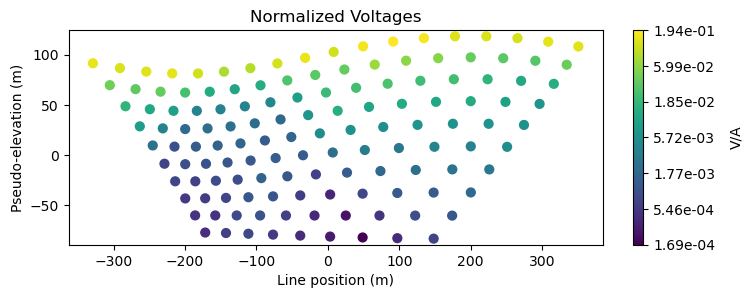

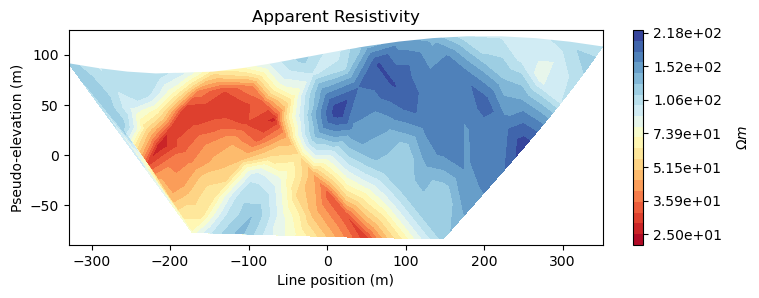

In [8]:
from simpeg.electromagnetics.static.utils.static_utils import (
    apparent_resistivity_from_voltage,
    plot_pseudosection,
)

# Plot voltages pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    voltage_data,
    plot_type="scatter",
    ax=ax1,
    scale="log",
    cbar_label="V/A",
    scatter_opts={"cmap": "viridis"},
)
ax1.set_title("Normalized Voltages")
plt.show()

# Get apparent conductivities from volts and survey geometry
apparent_resistivities = apparent_resistivity_from_voltage(
    voltage_data.survey, voltage_data.dobs
)

# Plot apparent resistivity pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    voltage_data.survey,
    apparent_resistivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label=r"$\Omega m$",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": "RdYlBu"},
)
ax1.set_title("Apparent Resistivity")
plt.show()

## Create mesh

In [9]:
dh = 4  # base cell width
dom_width_x = 3200.0  # domain width x
dom_width_z = 2400.0  # domain width z
nbcx = 2 ** int(np.round(np.log(dom_width_x / dh) / np.log(2.0)))  # num. base cells x
nbcz = 2 ** int(np.round(np.log(dom_width_z / dh) / np.log(2.0)))  # num. base cells z

# Define the base mesh with top at z = 0 m
hx = [(dh, nbcx)]
hz = [(dh, nbcz)]
mesh = discretize.TreeMesh([hx, hz], x0="CN", diagonal_balance=True)

# Shift top to maximum topography
mesh.origin = mesh.origin + np.r_[0.0, topo_2d[:, -1].max()]

# Mesh refinement based on topography
mesh.refine_surface(
    topo_2d,
    padding_cells_by_level=[0, 0, 4, 4],
    finalize=False,
)

# Extract unique electrode locations.
unique_locations = voltage_data.survey.unique_electrode_locations

# Mesh refinement near electrodes.
mesh.refine_points(
    unique_locations, padding_cells_by_level=[8, 12, 6, 6], finalize=False
)

mesh.finalize()

In [10]:
# Indices of the active mesh cells from topography (e.g. cells below surface)
active_cells = discretize.utils.active_from_xyz(mesh, topo_2d)

# number of active cells
n_active = np.sum(active_cells)

In [11]:
# Project electrodes to topography
voltage_data.survey.drape_electrodes_on_topography(mesh, active_cells, option="top")

/tmp/ipykernel_43433/2532513052.py:2: FutureWarning: Argument ``option`` is deprecated in favor of ``topo_cell_cutoff`` and will be removed in SimPEG v0.27.0.
  voltage_data.survey.drape_electrodes_on_topography(mesh, active_cells, option="top")


## Define simulation

In [12]:
# Map model parameters to all cells.
# We'll use log conductivities as model, so we need to pass an ExpMap
# to the simulation in order to convert log conductivities to conductivities.
log_conductivity_map = simpeg.maps.InjectActiveCells(
    mesh, active_cells, 1e-8
) * simpeg.maps.ExpMap(nP=n_active)

In [13]:
# Get median apparent resistivity
median_resistivity = np.median(apparent_resistivities)
median_conductivity = 1 / median_resistivity

# TODO: this is not the median conduct, right?
# Shall we do median_conductivity = np.median(1 / apparent_resistivities)?

# Create initial model (log conductivity)
initial_model = np.log(1 / median_resistivity) * np.ones(n_active)

In [14]:
solver = simpeg.utils.solver_utils.get_default_solver()
simulation_simpeg = dc.simulation_2d.Simulation2DNodal(
    mesh,
    survey=voltage_data.survey,
    sigmaMap=log_conductivity_map,
    storeJ=True,
    solver=solver,
)

In [15]:
# Assign a model to the simulation, just to set the correct size.
# We should improve this, allowing simulations to inform about the size of the expected model.
simulation_simpeg.model = initial_model

## Create inversion

Wrap the simulation into an object that can be used in the new framework.

In [16]:
# TODO: we should be able to set store_jacobian to True,
# but sensitivity weights don't currently support jacobians as LinearOperators.
simulation = ii.wrap_simulation(simulation_simpeg, store_jacobian=True)
simulation

Extract data and uncertainties from data object and build the data misfit

In [17]:
data = voltage_data.dobs
uncertainties = voltage_data.standard_deviation

data_misfit = ii.DataMisfit(data, uncertainties, simulation)

Define regularization (smallness) with sensitivity weights

In [18]:
# Get sensitivity weights
volumes = mesh.cell_volumes[active_cells]
sensitivity_weights = ii.utils.get_sensitivity_weights(
    simulation.jacobian(initial_model),
    data_weights=data_misfit.weights_matrix,
    volumes=volumes,
    vmin=0.01,
)
weights_dict = {
    "sensitivity": sensitivity_weights,
}

# Use the initial model as our reference model
reference_model = initial_model.copy()

alpha_s = 0.06
smallness = ii.Smallness(
    mesh=mesh,
    active_cells=active_cells,
    cell_weights=weights_dict,
    reference_model=initial_model,
)
smoothness_x, smoothness_y = tuple(
    ii.Flatness(
        mesh=mesh,
        active_cells=active_cells,
        direction=direction,
        cell_weights=weights_dict,
    )
    for direction in ("x", "y")
)

model_norm = (alpha_s * smallness + smoothness_x + smoothness_y).flatten()
model_norm

0.06 φs(m) + φx(m) + φy(m)

In [19]:
sensitivity_weights.min(), sensitivity_weights.max()

(np.float64(0.01), np.float64(1.0))

Build objective function

In [20]:
beta_0 = 5
regularization = beta_0 * model_norm
phi = data_misfit + regularization
phi

φd(m) + 5.00 [0.06 φs(m) + φx(m) + φy(m)]

## Gauss-Newton

Minimize the objective function with a fixed beta through Gauss Newton. The `ii.GaussNewtonConjugateGradient` minimizer builds a generator when called. We can iterate over it and get the model after each Gauss-Newton iteration.

In [21]:
# Evaluate the objective function on a random model to delete all cache
model_random = np.random.default_rng(seed=123132).uniform(size=initial_model.size)
phi(model_random)
phi.gradient(model_random)
phi.hessian(model_random)

<7205x7205 _SumLinearOperator with dtype=float64>

In [22]:
class Counter:
    def __init__(self):
        self.counter = 0

    def __call__(self, *args, **kwargs):  # noqa: ARG002
        self.counter += 1

    def __str__(self):
        return str(self.counter)

    def reset(self):
        self.counter = 0

In [23]:
print("Without preconditioner")
print("----------------------")
counter = Counter()
gauss_newton_minimizer = ii.GaussNewtonConjugateGradient(
    rtol=0.05, cg_kwargs={"callback": counter}
)
gauss_newton_generator = gauss_newton_minimizer(phi, initial_model)

start = time.perf_counter()
for i, model in enumerate(gauss_newton_generator):
    print(f"Finished iteration {i:2d}")
    print(f"  phi(model) = {phi(model):.2e}")
    print(f"  CG iterations: {counter}")
    counter.reset()
end = time.perf_counter()
print(f"Elapsed time: {end - start:.2e}s")

inverted_model = model

Without preconditioner
----------------------
Finished iteration  0
  phi(model) = 4.42e+04
  CG iterations: 0
Finished iteration  1
  phi(model) = 1.26e+04
  CG iterations: 151
Finished iteration  2
  phi(model) = 3.90e+03
  CG iterations: 131
Finished iteration  3
  phi(model) = 1.44e+03
  CG iterations: 118
Finished iteration  4
  phi(model) = 7.67e+02
  CG iterations: 136
Finished iteration  5
  phi(model) = 5.92e+02
  CG iterations: 146
Finished iteration  6
  phi(model) = 5.48e+02
  CG iterations: 153
Finished iteration  7
  phi(model) = 5.33e+02
  CG iterations: 158
Elapsed time: 6.07e+01s


In [24]:
print("With Jacobi preconditioner")
print("--------------------------")
preconditioner = ii.JacobiPreconditioner(phi)

counter = Counter()
gauss_newton_minimizer = ii.GaussNewtonConjugateGradient(
    rtol=0.05, cg_kwargs={"callback": counter}
)
gauss_newton_generator = gauss_newton_minimizer(
    phi, initial_model, preconditioner=preconditioner
)

start = time.perf_counter()
for i, model in enumerate(gauss_newton_generator):
    print(f"Finished iteration {i:2d}")
    print(f"  phi(model) = {phi(model):.2e}")
    print(f"  CG iterations: {counter}")
    counter.reset()
end = time.perf_counter()
print(f"Elapsed time: {end - start:.2e}s")

inverted_model = model

With Jacobi preconditioner
--------------------------
Finished iteration  0
  phi(model) = 4.42e+04
  CG iterations: 0
Finished iteration  1
  phi(model) = 1.26e+04
  CG iterations: 40
Finished iteration  2
  phi(model) = 3.90e+03
  CG iterations: 39
Finished iteration  3
  phi(model) = 1.44e+03
  CG iterations: 40
Finished iteration  4
  phi(model) = 7.67e+02
  CG iterations: 40
Finished iteration  5
  phi(model) = 5.92e+02
  CG iterations: 42
Finished iteration  6
  phi(model) = 5.48e+02
  CG iterations: 42
Finished iteration  7
  phi(model) = 5.33e+02
  CG iterations: 42
Elapsed time: 6.10e+01s


In [25]:
print("With BFGS preconditioner")
print("------------------------")
preconditioner = ii.BFGSPreconditioner(phi)

counter = Counter()
gauss_newton_minimizer = ii.GaussNewtonConjugateGradient(
    rtol=0.05, cg_kwargs={"callback": counter}
)
gauss_newton_generator = gauss_newton_minimizer(
    phi, initial_model, preconditioner=preconditioner
)

start = time.perf_counter()
for i, model in enumerate(gauss_newton_generator):
    print(f"Finished iteration {i:2d}")
    print(f"  phi(model) = {phi(model):.2e}")
    print(f"  CG iterations: {counter}")
    counter.reset()
end = time.perf_counter()
print(f"Elapsed time: {end - start:.2e}s")

inverted_model = model

With BFGS preconditioner
------------------------
Finished iteration  0
  phi(model) = 4.42e+04
  CG iterations: 0
Finished iteration  1
  phi(model) = 1.26e+04
  CG iterations: 151
Finished iteration  2
  phi(model) = 3.90e+03
  CG iterations: 155
Finished iteration  3
  phi(model) = 1.44e+03
  CG iterations: 147
Finished iteration  4
  phi(model) = 7.67e+02
  CG iterations: 163
Finished iteration  5
  phi(model) = 5.92e+02
  CG iterations: 169
Finished iteration  6
  phi(model) = 5.48e+02
  CG iterations: 183
Finished iteration  7
  phi(model) = 5.33e+02
  CG iterations: 194
Elapsed time: 6.05e+01s


In [26]:
print("With BFGS preconditioner + initial matrix")
print("-----------------------------------------")

# Estimate the initial preconditioner as the Jacobi preconditioner of the regularization
# This is useful when we don't want to (or can't) compute the jacobi of the data misfit.
initial_matrix = ii.get_jacobi_preconditioner(regularization, initial_model)
preconditioner = ii.BFGSPreconditioner(phi, initial_matrix=initial_matrix)

counter = Counter()
gauss_newton_minimizer = ii.GaussNewtonConjugateGradient(
    rtol=0.05, cg_kwargs={"callback": counter}
)
gauss_newton_generator = gauss_newton_minimizer(
    phi, initial_model, preconditioner=preconditioner
)

start = time.perf_counter()
for i, model in enumerate(gauss_newton_generator):
    print(f"Finished iteration {i:2d}")
    print(f"  phi(model) = {phi(model):.2e}")
    print(f"  CG iterations: {counter}")
    counter.reset()
end = time.perf_counter()
print(f"Elapsed time: {end - start:.2e}s")

inverted_model = model

With BFGS preconditioner + initial matrix
-----------------------------------------
Finished iteration  0
  phi(model) = 4.42e+04
  CG iterations: 0
Finished iteration  1
  phi(model) = 1.26e+04
  CG iterations: 40
Finished iteration  2
  phi(model) = 3.90e+03
  CG iterations: 49
Finished iteration  3
  phi(model) = 1.44e+03
  CG iterations: 54
Finished iteration  4
  phi(model) = 7.67e+02
  CG iterations: 56
Finished iteration  5
  phi(model) = 5.92e+02
  CG iterations: 55
Finished iteration  6
  phi(model) = 5.48e+02
  CG iterations: 57
Finished iteration  7
  phi(model) = 5.33e+02
  CG iterations: 57
Elapsed time: 5.86e+01s


In [27]:
data_misfit.chi_factor(inverted_model)

np.float64(0.8321826927140525)

In [28]:
inverted_conductivity = np.exp(inverted_model)

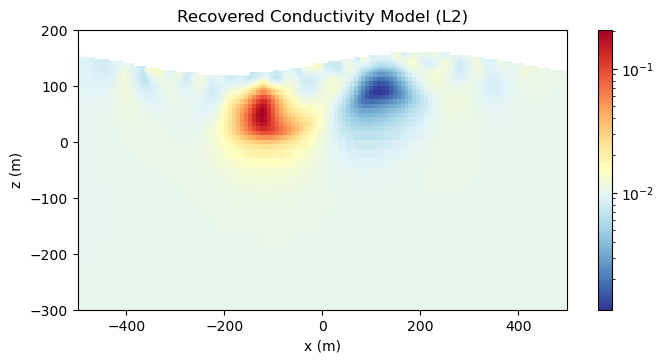

In [29]:
norm = LogNorm()
plotting_map = simpeg.maps.InjectActiveCells(mesh, active_cells, np.nan)

fig = plt.figure(figsize=(9, 4))

ax1 = fig.add_axes([0.14, 0.17, 0.68, 0.7])
(tmp,) = mesh.plot_image(
    plotting_map * inverted_conductivity,
    normal="Y",
    ax=ax1,
    grid=False,
    pcolor_opts={"norm": norm, "cmap": "RdYlBu_r"},
)
ax1.set_xlim(-500, 500)
ax1.set_ylim(-300, 200)
ax1.set_title("Recovered Conductivity Model (L2)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

# ax2 = fig.add_axes([0.84, 0.17, 0.03, 0.7])
# cbar = mpl.colorbar.ColorbarBase(
#     ax2, norm=norm, orientation="vertical", cmap="RdYlBu_r"
# )
plt.colorbar(tmp, ax=ax1, norm=norm, orientation="vertical")
# cbar.set_label(r"$\sigma$ (S/m)", rotation=270, labelpad=15, size=12)

plt.show()

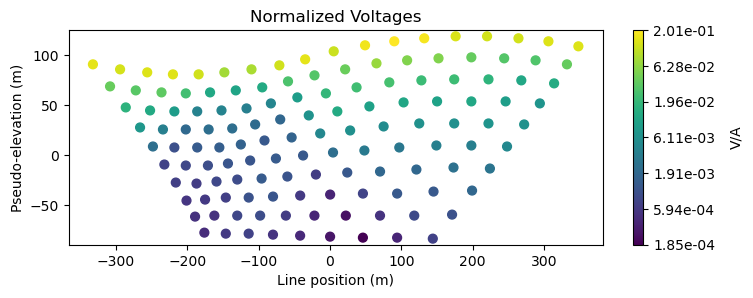

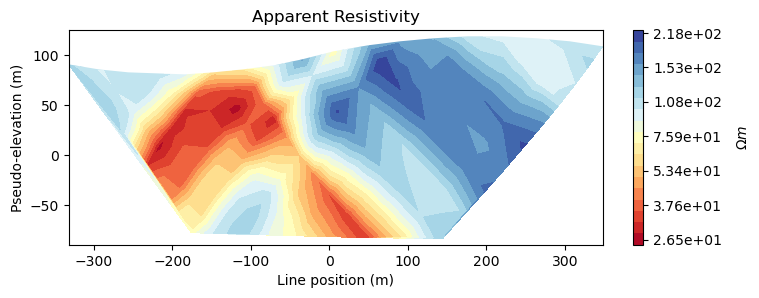

In [30]:
dpred = simulation(inverted_model)


prediction = simpeg.Data(voltage_data.survey, dobs=dpred)

# Plot voltages pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    prediction,
    plot_type="scatter",
    ax=ax1,
    scale="log",
    cbar_label="V/A",
    scatter_opts={"cmap": "viridis"},
)
ax1.set_title("Normalized Voltages")
plt.show()

# Get apparent conductivities from volts and survey geometry
apparent_resistivities = apparent_resistivity_from_voltage(voltage_data.survey, dpred)

# Plot apparent resistivity pseudo-section
fig = plt.figure(figsize=(8, 2.75))
ax1 = fig.add_axes([0.1, 0.15, 0.75, 0.78])
plot_pseudosection(
    voltage_data.survey,
    apparent_resistivities,
    plot_type="contourf",
    ax=ax1,
    scale="log",
    cbar_label=r"$\Omega m$",
    mask_topography=True,
    contourf_opts={"levels": 20, "cmap": "RdYlBu"},
)
ax1.set_title("Apparent Resistivity")
plt.show()